# Image basics and thresholding

## Images are matrices of numerical values

<img src="illustrations/image_as_strings.png" alt="drawing" width="40%" class="center"/>

<sub>Illustration by Jean-Yves Tinevez</sub>

### Importing the necessary python packages

In [1]:
import os # interact with the file system
import numpy as np # image array processing
import matplotlib.pyplot as plt # visualization
import skimage # image processing
import stackview # visualization

## Recap: images as arrays
How are images stored in memory? As arrays of numerical values.
In 2D, this can be a list of lists, or a 2D numpy array.

Image shape: (5, 7)


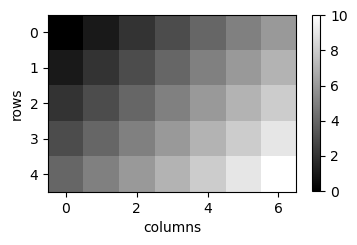

In [10]:
# draw a 5x7 image of a gradient increasing from the top-left to the bottom-right corner
my_image_list = [
    [0, 1, 2, 3, 4, 5, 6],
    [1, 2, 3, 4, 5, 6, 7],
    [2, 3, 4, 5, 6, 7, 8],
    [3, 4, 5, 6, 7, 8, 9],
    [4, 5, 6, 7, 8, 9, 10],
]

my_image_array = np.array(my_image_list)

plt.figure(figsize=(4,4))
plt.imshow(my_image_array, cmap='gray', interpolation='nearest')
plt.colorbar(shrink=0.57)
plt.xlabel('columns')
plt.ylabel('rows')

print('Image shape:', my_image_array.shape)

## Recap: Loading and displaying images

We will use the `scikit-image` package (which is confusingly imported using the name `skimage`) to load an image into a numpy array and use the `stackview` package to display it.

The image is from an online microscopy repository and we can either use a URL to load it, or open a local copy in the `images` folder.

In [18]:
# OPTION 1: download image from online repository
# image = skimage.io.imread('https://cildata.crbs.ucsd.edu/media/images/13901/13901.tif')

# OPTION 2: load local copy
image = skimage.io.imread('images/cells_atlas/27985_284_E10_2.tif')

We can enquire about the dimensions of the variable `image` by using the numpy function [`shape`](https://numpy.org/doc/stable/reference/generated/numpy.shape.html).

In [20]:
print("The image dimensions are:", image.shape)

The image dimensions are: (2048, 2048, 3)


The numpy array containing the image has 3 dimensions (X,Y,C). We can subset the array to create a new variable for each channel, and visualise them separately using `matplotlib.pyplot`

In [21]:
image_microtubules = image[:, :, 0]
image_membrane = image[:, :, 1]
image_nuclei = image[:, :, 2]

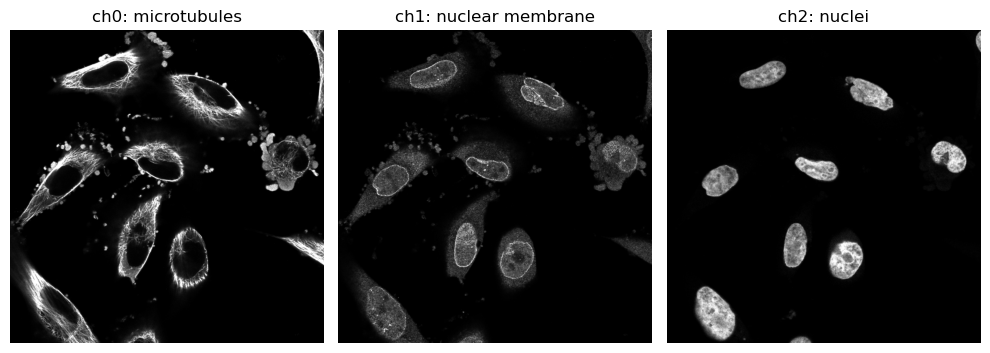

In [23]:
# display all channels 
fig, axs = plt.subplots(1, 3, figsize=(10,8))

axs[0].imshow(image_microtubules, cmap='gray')
axs[0].set_title('ch0: microtubules')
axs[0].axis('off')

axs[1].imshow(image_membrane, cmap='gray')
axs[1].set_title('ch1: nuclear membrane')
axs[1].axis('off')

axs[2].imshow(image_nuclei, cmap='gray')
axs[2].set_title('ch2: nuclei')
axs[2].axis('off')

plt.tight_layout()

We can also use an image analysis-specific library, [`stackview`](https://github.com/haesleinhuepf/stackview), to visualise the image as a composite of the three channels.

[[[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [123  23   1]
  [110  36   0]
  [127  47   0]]

 [[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [104  25  10]
  [ 80  17  14]
  [ 96  24   6]]

 [[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [127  27   8]
  [ 94  26   9]
  [ 81  17   4]]

 ...

 [[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [  0   0   0]
  [  0   0   0]
  [  0   0   0]]

 [[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [  0   0   0]
  [  0   0   0]
  [  0   0   0]]

 [[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [  0   0   0]
  [  0   0   0]
  [  0   0   0]]]
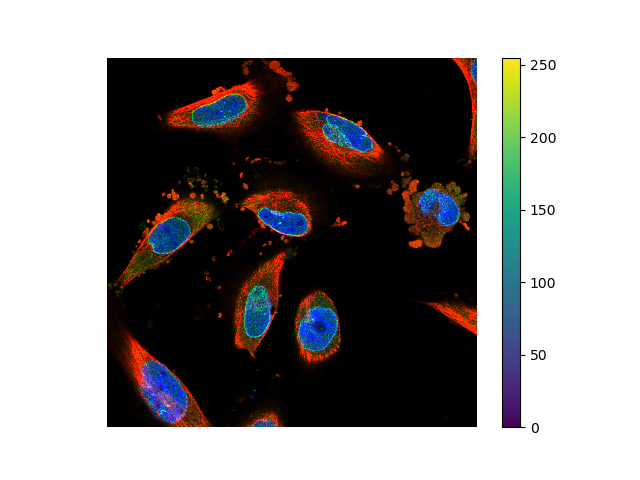
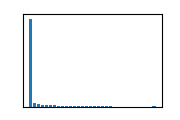

In [24]:
stackview.insight(image)

We can zoom in on a specific region of the image by subsetting the numpy array in (X,Y)

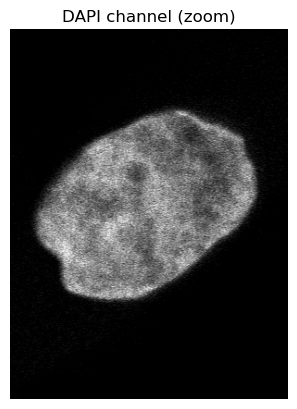

In [25]:
image_dapi_cropped = image_dapi[800: 1200, 200: 500]

plt.imshow(image_dapi_cropped, cmap='gray')

plt.title('DAPI channel (zoom)')
plt.axis('off')

plt.show()

### Displaying the histogram

The histogram of an image is a plot of the frequency of each intensity value. It is a useful tool to understand the distribution of intensities in an image.

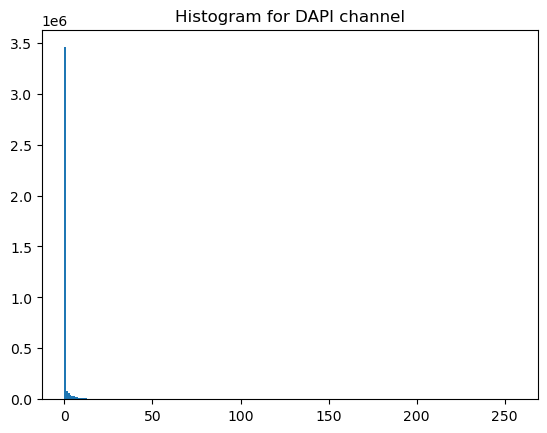

In [30]:
plt.hist(image_dapi.flatten(), bins=256, range=(0.0, 256))
plt.title('Histogram for DAPI channel')
plt.show()

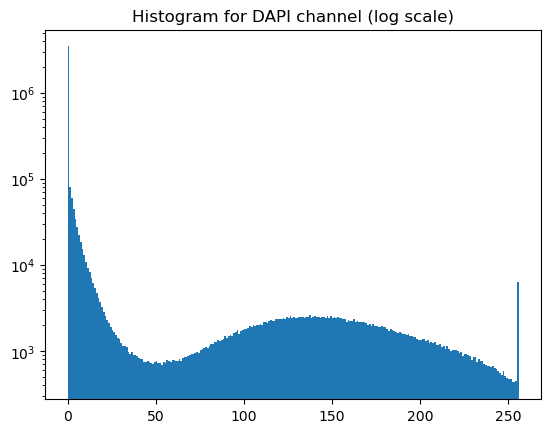

In [31]:
plt.hist(image_dapi.flatten(), bins=256, range=(0.0, 256), log=True)
plt.title('Histogram for DAPI channel (log scale)')
plt.show()

## How to quantitatively analyse images?

Let's load two example images from the `images` folder

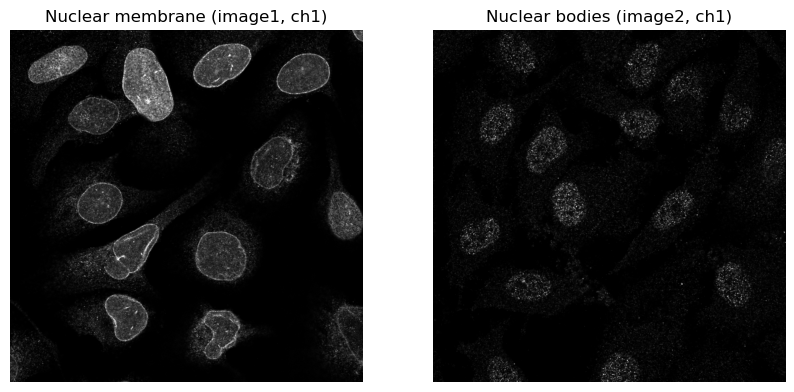

In [38]:
# open images
image1 = skimage.io.imread('images/cells_atlas/50546_727_A8_2.tif')
image2 = skimage.io.imread('images/cells_atlas/67703_1283_D7_3.tif')

# select second channel (green)
image1 = image1[:, :, 1]
image2 = image2[:, :, 1]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(image1, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Nuclear membrane (image1, ch1)')
ax[0].axis('off')

ax[1].imshow(image2, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Nuclear bodies (image2, ch1)')
ax[1].axis('off')

plt.show()

We can perform basic quantification by computing the overall statistics for the numpy array containing the image. This allows us to quantify signal intensity for the whole field of view with metrics such as mean, median, standard deviation, etc.

In [42]:
image1_mean_intensity = image1.mean()
image1_std_intensity = image1.std()

image2_mean_intensity = image2.mean()
image2_std_intensity = image2.std()

In [46]:
print(f'Image1 signal intensity mean±std: {image1_mean_intensity:.2f} ± {image1_std_intensity:.2f}')
print(f'Image2 signal intensity mean±std: {image2_mean_intensity:.2f} ± {image2_std_intensity:.2f}')

Image1 signal intensity mean±std: 16.19 ± 30.10
Image2 signal intensity mean±std: 7.24 ± 15.42


## How to make use of spatial information in images?

We can extend the approach we've just seen to compute statistics for different regions of the image. To achieve this, we first need to partition the image into distinct regions, using a process called **image segmentation**. 

The first step is to binarise the image, deciding for each pixel whether it belongs to the foreground or the background. The easiest approach to obtain a binary mask from an image is **thresholding**. This involves splitting the histogram into two separate regions by selecting a threshold: any pixels with values above the threshold will be considered foreground, any pixels with values below the threshold will be considered background.

<img src="illustrations/thresholding.png" alt="drawing" width="50%" class="center"/>

<sub>Illustration by Jean-Yves Tinevez</sub>

<img src="illustrations/manual_threshold.png" alt="drawing" width="90%" class="center"/>

<sub>Illustration taken from "Introduction to Bioimage Analysis" by Pete Bankhead, [CC-BY 4.0](https://creativecommons.org/licenses/by/4.0/).</sub>

## Thresholding in Python

Let's load the DAPI channel for one of our example images and visualise it together with its histogram.

[[  0   0   0 ... 112 127 124]
 [  0   0   0 ... 120 124 135]
 [  0   0   0 ... 129 133 125]
 ...
 [209 206 216 ...   0   0   0]
 [163 161 189 ...   0   0   0]
 [167 166 182 ...   0   0   0]]
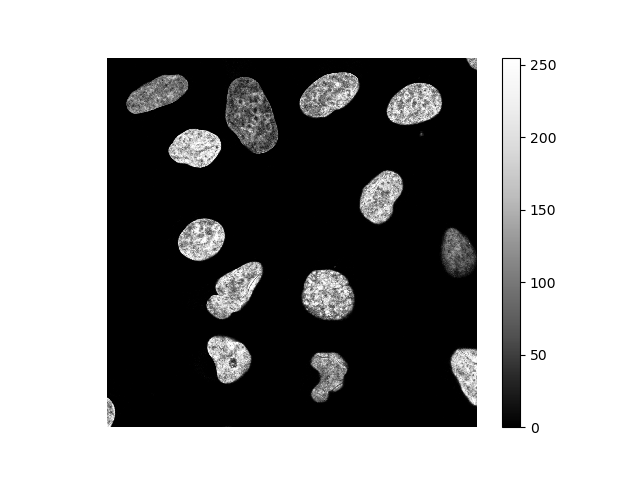
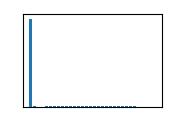

In [47]:
image = skimage.io.imread('images/cells_atlas/50546_727_A8_2.tif')
image_dapi = image[:, :, 2]

stackview.insight(image_dapi)

We can manually set a threshold to a value which we believe could successfully split the pixels into foreground and background based on their intensity. We can create a new Boolean variable called `image_thresholded` where any pixels above the threshold will be marked as `True`, and any pixels below the threshold will be marked as `False`.

[[0 0 0 ... 1 1 1]
 [0 0 0 ... 1 1 1]
 [0 0 0 ... 1 1 1]
 ...
 [1 1 1 ... 0 0 0]
 [1 1 1 ... 0 0 0]
 [1 1 1 ... 0 0 0]]
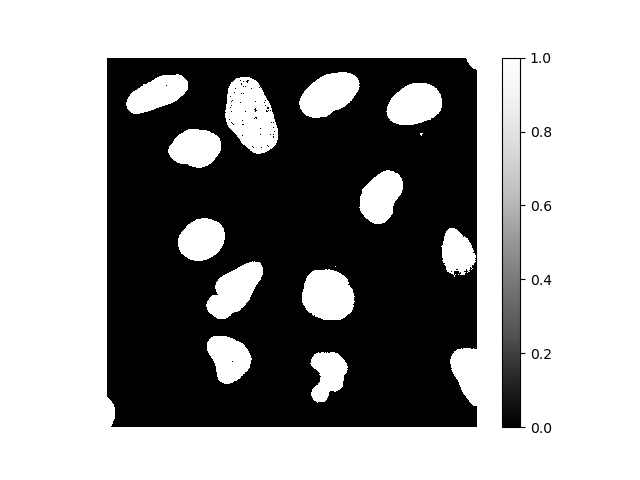
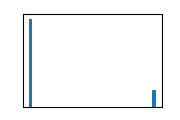

In [49]:
image_thresholded = image_dapi > 30

stackview.insight(np.uint8(image_thresholded))

In [50]:
print('Values at position [200, 200]')
print('image:', image_dapi[200, 200])
print('image_thresholded:', image_thresholded[200, 200])

Values at position [200, 200]
image: 70
image_thresholded: True


Setting a threshold value manually has some limitations:
1. The chosen value might not be suitable for other images in the same sample
2. We might be biased by what "we want to see" in the image
3. It might be affected by external factors such as screen quality, resolution and brightness
4. It's not a reproducible approach

For these reasons, it is always a good idea to use an algorithm to find a suitable thresholding value. A few classic image processing thresholding algorithms are implemented in `scikit-image` in the `filters` module (more information [here](https://scikit-image.org/docs/stable/auto_examples/applications/plot_thresholding_guide.html)). 

Different thresholding algorithms rely on different mathematical principles to split the histogram into two parts (foreground/background). For example, the [**Otsu's method**](https://en.wikipedia.org/wiki/Otsu%27s_method) maximises the inter-class variance:

<!-- <img src="illustrations/otsu.gif" alt="drawing" width="50%" class="center"/> -->
<img src="illustrations/otsu_inter.webp" alt="drawing" width="50%" class="center"/>

<sub>Illustration taken from ["The AI Learner"](https://www.google.com/url?sa=i&url=https%3A%2F%2Ftheailearner.com%2F2019%2F07%2F19%2Foptimum-global-thresholding-using-otsus-method%2F&psig=AOvVaw0xiEsQJVjxpyoMKz7s4OgU&ust=1728415367785000&source=images&cd=vfe&opi=89978449&ved=0CBQQjhxqFwoTCOiOn5P__IgDFQAAAAAdAAAAABAX).</sub>

With the function [`skimage.filters.try_all_threshold`](https://scikit-image.org/docs/stable/api/skimage.filters.html#skimage.filters.try_all_threshold), we can visualise a few options and decide which one performs best for our data. 

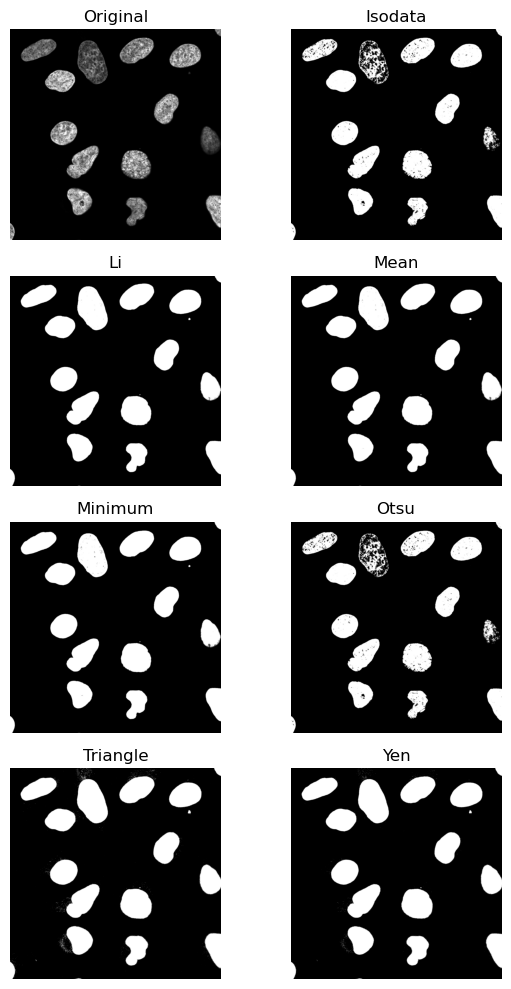

In [54]:
# display various options for gray level thresholding
fig, ax = skimage.filters.try_all_threshold(image_dapi, figsize=(8,10), verbose=False)
plt.tight_layout()

The [Li algorithm](https://scikit-image.org/docs/stable/auto_examples/developers/plot_threshold_li.html) looks appropriate for our nuclear segmentation task. We will go ahead and apply it as follows:

In [57]:
threshold_li = skimage.filters.threshold_li(image_dapi)
image_thresholded_li = image_dapi > threshold_li
print(f'Li says: {threshold_li:.2f}')

Li says: 18.38


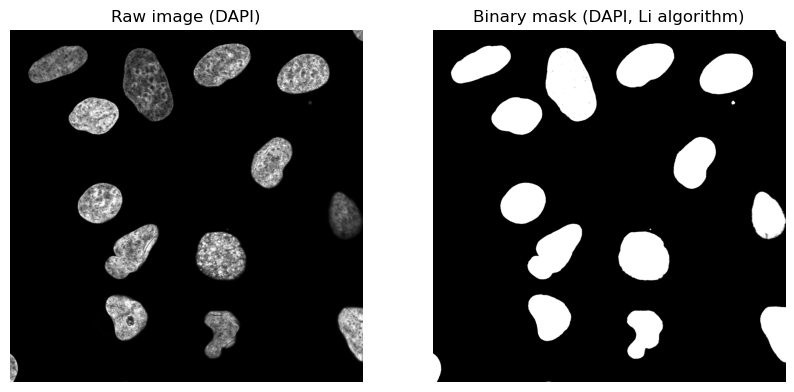

In [61]:
fig, ax = plt.subplots(1, 2, figsize=(10, 8))

ax[0].imshow(image_dapi, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Raw image (DAPI)')
ax[0].axis('off')

ax[1].imshow(image_thresholded_li, cmap='gray')
ax[1].set_title('Binary mask (DAPI, Li algorithm)')
ax[1].axis('off')

plt.show()

## Limits of global thresholding

In some situations, finding a single threshold value might not be appropriate or sufficient. For example, when the histogram is not bimodal, this approach will fail, as we can see from the example below:

[[219 225 220 ... 256 258 272]
 [218 211 217 ... 270 268 278]
 [217 217 214 ... 263 268 262]
 ...
 [337 343 321 ... 266 287 285]
 [320 323 339 ... 268 295 281]
 [329 353 335 ... 276 281 291]]
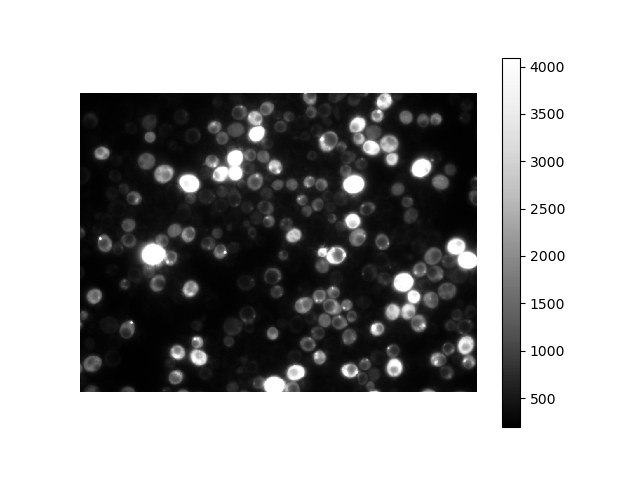
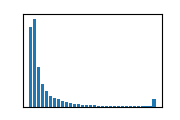

In [62]:
# This is fluorescence microscopy image of Saccharomyces cerevisiae with a signal accumulating in the vacuoles.
# Taken from the Cell Image Library (CIL).
image = skimage.io.imread('https://cildata.crbs.ucsd.edu/media/images/13901/13901.tif')

stackview.insight(image)

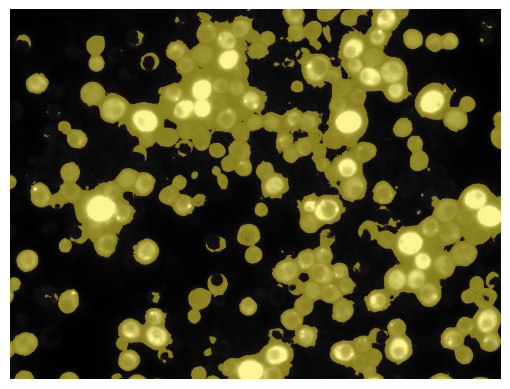

In [65]:
# no threshold works well for all regions of the image

image_tresholded = image > 500

plt.figure()
plt.imshow(image, cmap='grey')
plt.imshow(image_tresholded, alpha=image_tresholded * 0.5)

plt.axis('off')

plt.show()